In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys
import os

REPO_PATH = "/content/drive/MyDrive/BraTS_Project/brats-brain-tumor"
SRC_PATH = os.path.join(REPO_PATH, "src")

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print(f"Added to path: {SRC_PATH}")

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from dataset import BraTSDataGenerator
from preprocess import split_data
from model import hybrid_loss, dice_coefficient, build_model

Added to path: /content/drive/MyDrive/BraTS_Project/brats-brain-tumor/src


In [ ]:
# Önce projenin olduğu klasöre git
%cd /content/drive/MyDrive/BraTS_Project/brats-brain-tumor

# Sonra arkadaşının gönderdiği güncellemeleri çek
!git pull origin main

/content/drive/MyDrive/BraTS_Project/brats-brain-tumor
From https://github.com/miraytopcu/brats-brain-tumor
 * branch            main       -> FETCH_HEAD
   616f462..fc5f0ef  main       -> origin/main
Already up to date.


Training with Standart U-Net Model

In [ ]:
!python {REPO_PATH}/src/train.py --model unet

2026-05-05 14:50:03.897743: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 14:50:03.959095: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 14:50:14.642391: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777992614.643387    1624 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79188 MB memory:  -> device: 0, nam

Training with Attention U-Net Model

In [5]:
!python {REPO_PATH}/src/train.py --model attention

2026-05-06 09:20:56.581826: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778059256.582954    2120 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79188 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:00:05.0, compute capability: 8.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()

Training with ResU-Net Model

In [6]:
!python {REPO_PATH}/src/train.py --model resunet

2026-05-06 11:54:30.816668: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778068470.817787   42758 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79188 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:00:05.0, compute capability: 8.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()

U-Net Analysis

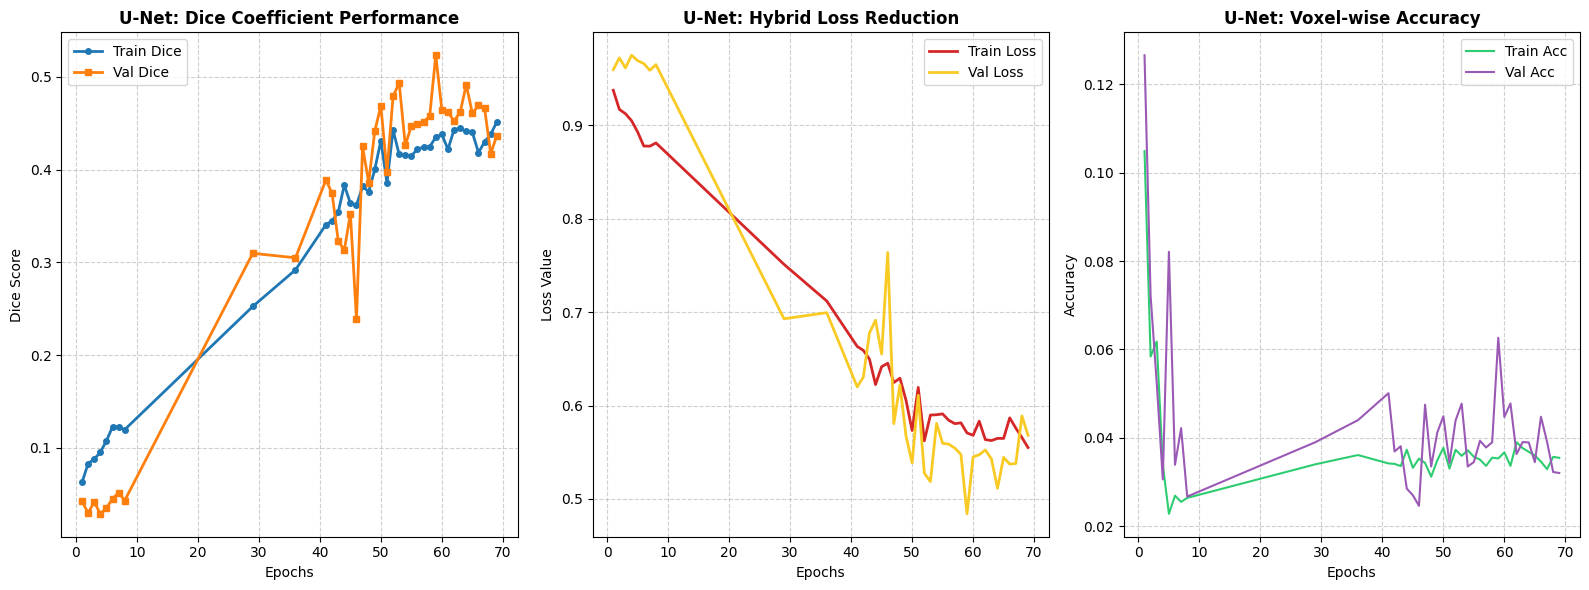

In [ ]:
log_path = '/content/drive/MyDrive/BraTS_Project/brats-brain-tumor/models/unet_training_log.csv'
df = pd.read_csv(log_path)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))
plt.rcParams.update({'font.size': 10})

# --- DICE COEFFICIENT ---
ax1.plot(df['epoch'], df['dice_coefficient'], label='Train Dice', color='#1f77b4', linewidth=2, marker='o', markersize=4)
ax1.plot(df['epoch'], df['val_dice_coefficient'], label='Val Dice', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
ax1.set_title('U-Net: Dice Coefficient Performance', fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Dice Score')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# --- LOSS CURVE ---
ax2.plot(df['epoch'], df['loss'], label='Train Loss', color='#d62728', linewidth=2)
ax2.plot(df['epoch'], df['val_loss'], label='Val Loss', color='#f9ca24', linewidth=2)
ax2.set_title('U-Net: Hybrid Loss Reduction', fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Value')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# --- ACCURACY ANALYSIS ---
ax3.plot(df['epoch'], df['accuracy'], label='Train Acc', color='#2ecc71')
ax3.plot(df['epoch'], df['val_accuracy'], label='Val Acc', color='#9b59b6')
ax3.set_title('U-Net: Voxel-wise Accuracy', fontweight='bold')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Accuracy')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend()

plt.tight_layout()
plt.savefig('unet_performance_report.png', dpi=300)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


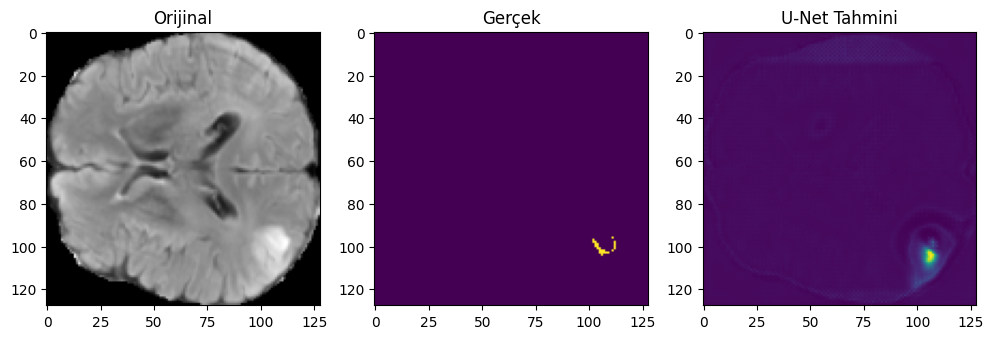

In [ ]:
DATA_PATH = "/content/drive/MyDrive/BraTS_Project/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

patient_ids = sorted([f for f in os.listdir(DATA_PATH) if f.startswith("BraTS20")])
train_ids, val_ids, test_ids = split_data(patient_ids)

val_gen = BraTSDataGenerator(val_ids, DATA_PATH, batch_size=8, shuffle=False)

MODEL_TYPE = "unet"
checkpoint_path = os.path.join(REPO_PATH, f"models/best_{MODEL_TYPE}_model.keras")
sys.path.append(os.path.join(REPO_PATH, "src"))

model = tf.keras.models.load_model(checkpoint_path, custom_objects={
    'hybrid_loss': hybrid_loss,
    'dice_coefficient': dice_coefficient
})

sample_batch = val_gen[0]
images, masks = sample_batch
preds = model.predict(images)

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(images[0,:,:,0], cmap='gray'); plt.title("Orijinal")
plt.subplot(1,3,2); plt.imshow(masks[0,:,:,0]); plt.title("Gerçek")
plt.subplot(1,3,3); plt.imshow(preds[0,:,:,0]); plt.title("U-Net Tahmini")
plt.show()

In [ ]:
from scipy.spatial.distance import directed_hausdorff
import numpy as np

def calculate_metrics(y_true, y_pred):
    y_pred_bin = (y_pred > 0.5).astype(np.float32)

    # 1. Per-Class Dice
    intersection = np.sum(y_true * y_pred_bin)
    dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_bin) + 1e-6)

    # 2. HD95 (Basitleştirilmiş Hausdorff)
    y_true_points = np.argwhere(y_true[..., 0] > 0.5)
    y_pred_points = np.argwhere(y_pred_bin[..., 0] > 0.5)

    hd = 0
    if len(y_true_points) > 0 and len(y_pred_points) > 0:
        d1 = directed_hausdorff(y_true_points, y_pred_points)[0]
        d2 = directed_hausdorff(y_pred_points, y_true_points)[0]
        hd = max(d1, d2)

    return dice, hd

# Test paketi üzerinde çalıştır
dice_list, hd_list = [], []
for i in range(len(images)):
    d, h = calculate_metrics(masks[i], preds[i])
    dice_list.append(d); hd_list.append(h)

print(f"Ortalama Dice: {np.mean(dice_list):.4f}")
print(f"Ortalama Hausdorff Distance: {np.mean(hd_list):.4f}")

Ortalama Dice: 0.5207
Ortalama Hausdorff Distance: 10.0694


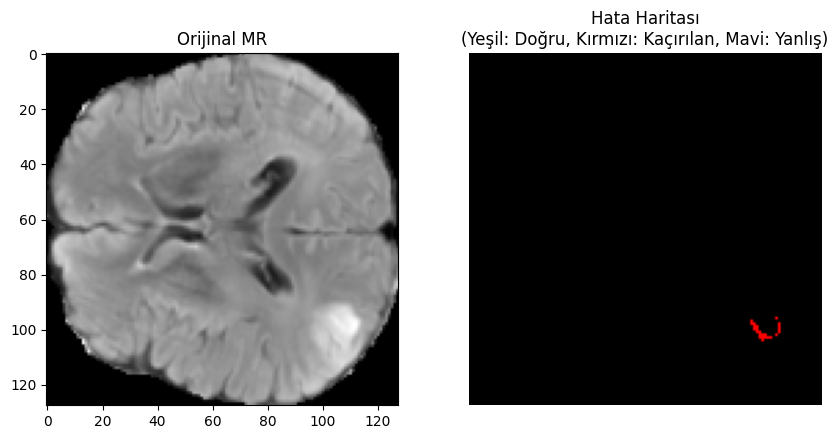

In [ ]:
def plot_error_map(image, mask, pred):
    # Tahmini binary yap
    pred_bin = (pred > 0.5).astype(np.float32)

    # Hata: Eğer mask ve pred_bin 3 kanallıysa (128, 128, 3),
    # sadece ilk kanalı alalım ki (128, 128) olsun.
    m = mask[..., 0]
    p = pred_bin[..., 0]

    # TP: Yeşil, FP: Mavi, FN: Kırmızı
    error_map = np.zeros((128, 128, 3))

    # np.squeeze kullanarak boyutları (128, 128) olduğundan emin oluyoruz
    error_map[..., 1] = np.minimum(m, p) # TP (Yeşil)
    error_map[..., 2] = np.maximum(p - m, 0) # FP (Mavi)
    error_map[..., 0] = np.maximum(m - p, 0) # FN (Kırmızı)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image[..., 0], cmap='gray')
    plt.title("Orijinal MR")

    plt.subplot(1, 2, 2)
    plt.imshow(error_map)
    plt.title("Hata Haritası\n(Yeşil: Doğru, Kırmızı: Kaçırılan, Mavi: Yanlış)")
    plt.axis('off')
    plt.show()

# İlk örnek için tekrar dene
plot_error_map(images[0], masks[0], preds[0])

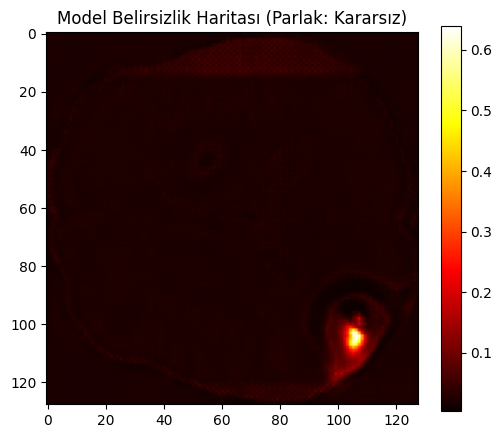

In [ ]:
def plot_uncertainty(pred):
    # Entropi veya basitçe 0.5'e yakınlık
    uncertainty = 1 - np.abs(2 * pred - 1)

    plt.figure(figsize=(6, 5))
    plt.imshow(uncertainty[..., 0], cmap='hot')
    plt.colorbar()
    plt.title("Model Belirsizlik Haritası (Parlak: Kararsız)")
    plt.show()

plot_uncertainty(preds[0])

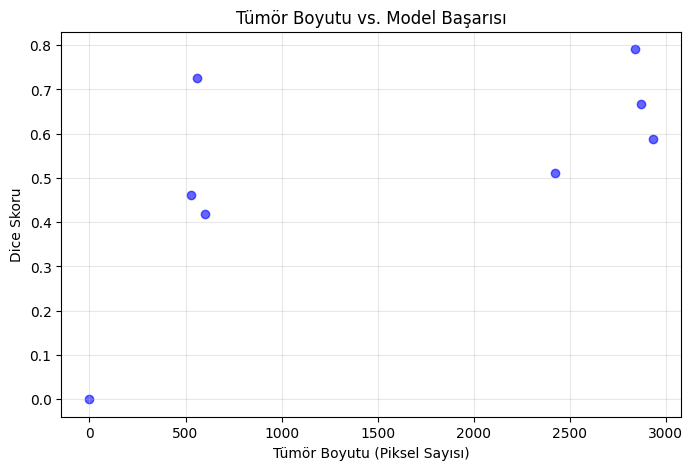

In [ ]:
tumor_sizes = [np.sum(m) for m in masks]
dices = dice_list

plt.figure(figsize=(8, 5))
plt.scatter(tumor_sizes, dices, alpha=0.6, c='blue')
plt.xlabel("Tümör Boyutu (Piksel Sayısı)")
plt.ylabel("Dice Skoru")
plt.title("Tümör Boyutu vs. Model Başarısı")
plt.grid(True, alpha=0.3)
plt.show()

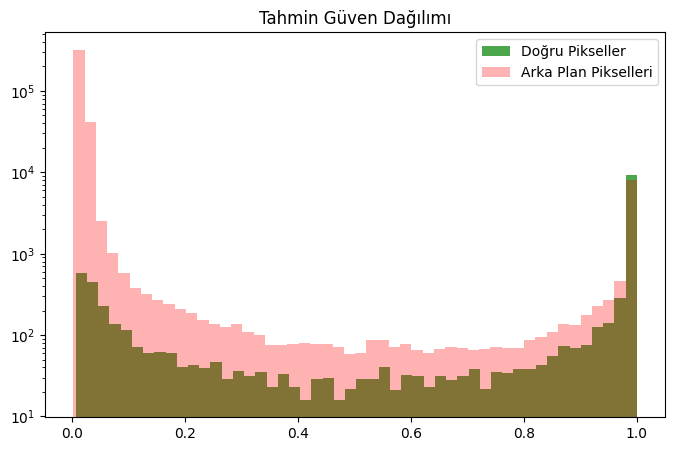

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(preds[masks > 0.5].flatten(), bins=50, color='green', alpha=0.7, label='Doğru Pikseller')
plt.hist(preds[masks < 0.5].flatten(), bins=50, color='red', alpha=0.3, label='Arka Plan Pikselleri')
plt.yscale('log')
plt.title("Tahmin Güven Dağılımı")
plt.legend()
plt.show()